## Phase 1. Baseline: 반도체 공통 모델 구축 및 가설 검증

### 프로젝트 개요
- **주제**: 머신러닝 기반 반도체 주식 상승 확률 예측 및 투자 전략 백테스팅
- **핵심 가치**: 단순 가격 예측(Regression)이 아닌, 통계적 상승 확률(Classification)에 기반한 의사결정 시스템
- **타겟 섹터**: AI 반도체 (NVIDIA, TSMC, AMD, ASML, Qualcomm)

### 연구 가설
> "반도체 산업은 특유의 수요 사이클과 기술 이벤트에 민감하며,
> RSI·거래량 변화율 등 기술적 지표가 주가 반등의 유의미한 신호로 작용할 것이다."

### Phase 1 목표
1. 5개 종목 통합 데이터셋 구축 (공통 모델)
2. Random Forest로 상승 확률 학습
3. Feature Importance로 가설 검증
4. 백테스팅으로 전략 유효성 확인

In [1]:
import sys
import os
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

from src.data_loader import download_all, load_all_combined
from src.features   import process_all, build_combined_dataset
from src.model      import split_data, train_model, evaluate_model, get_feature_importance
from src.backtest   import generate_signals, calculate_returns, summarize_performance, plot_cumulative_returns

print("라이브러리 로드 완료")

c:\Users\user\miniconda3\envs\semiconductor\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


라이브러리 로드 완료


## 1. 데이터 수집 및 전처리

### 수집 종목
| 티커 | 기업 | 역할 |
|------|------|------|
| NVDA | NVIDIA | AI 반도체 설계 대장주 |
| TSM | TSMC | 파운드리 1위 |
| AMD | AMD | NVIDIA 대항마 |
| ASML | ASML | 반도체 장비 독점 |
| QCOM | Qualcomm | 모바일 반도체 |

### 수집 기간
- 2018년 1월 ~ 2025년 12월 (약 8년)
- AI 붐 이전과 이후를 모두 포함 → 다양한 사이클 학습 가능

### 데이터 흐름
```
yfinance → data/raw/ (원본)
        → features.py (지표 추가)
        → data/processed/ (가공)
```

In [2]:
# ── 데이터 수집 및 전처리 ────────────────────────────────────
stock_data = download_all(save_csv=False)
processed  = process_all(stock_data, save_csv=True)
combined   = build_combined_dataset(processed)

# 데이터 확인
print(f"\n총 행 수    : {len(combined)}")
print(f"컬럼 수     : {combined.shape[1]}")
print(f"컬럼 목록   : {combined.columns.tolist()}")
print(f"\nTarget 분포:")
print(combined["Target"].value_counts())
display(combined.head(3))


[NVDA] 다운로드 중...
[NVDA] 완료 → 2010행, 2018-01-02 ~ 2025-12-30
[TSM] 다운로드 중...
[TSM] 완료 → 2010행, 2018-01-02 ~ 2025-12-30
[AMD] 다운로드 중...
[AMD] 완료 → 2010행, 2018-01-02 ~ 2025-12-30
[ASML] 다운로드 중...
[ASML] 완료 → 2010행, 2018-01-02 ~ 2025-12-30
[QCOM] 다운로드 중...
[QCOM] 완료 → 2010행, 2018-01-02 ~ 2025-12-30
전체 5개 종목 다운로드 완료
[NVDA] 전처리 중...
  결측값 제거: 2010행 → 1977행 (33행 제거)
[NVDA] 완료 → 1977행, 16개 컬럼

[NVDA] 저장 완료 → c:\ML-SCAMP\notebooks\..\src\..\data\processed\NVDA_processed.csv

[TSM] 전처리 중...
  결측값 제거: 2010행 → 1977행 (33행 제거)
[TSM] 완료 → 1977행, 16개 컬럼

[TSM] 저장 완료 → c:\ML-SCAMP\notebooks\..\src\..\data\processed\TSM_processed.csv

[AMD] 전처리 중...
  결측값 제거: 2010행 → 1977행 (33행 제거)
[AMD] 완료 → 1977행, 16개 컬럼

[AMD] 저장 완료 → c:\ML-SCAMP\notebooks\..\src\..\data\processed\AMD_processed.csv

[ASML] 전처리 중...
  결측값 제거: 2010행 → 1977행 (33행 제거)
[ASML] 완료 → 1977행, 16개 컬럼

[ASML] 저장 완료 → c:\ML-SCAMP\notebooks\..\src\..\data\processed\ASML_processed.csv

[QCOM] 전처리 중...
  결측값 제거: 2010행 → 1977행 (33행 제거)
[QCOM] 완료 → 19

Price,Close,High,Low,Open,Volume,Ticker,RSI,MACD,MACD_signal,BB_upper,BB_lower,BB_width,Volume_ratio,Return_1d,Return_5d,Target
Date,,,,,,,,,,,,,,,,
2018-02-20,6.157676,6.226650,6.046923,6.050631,686240000,NVDA,62.087508,0.140230,0.107859,6.308191,5.367758,0.152725,0.908225,0.021490,0.092313,0
2018-02-20,51.637596,51.758639,49.918763,50.846769,27494600,QCOM,43.819665,-0.356418,-0.329554,56.191355,50.113991,0.117693,1.861736,-0.013262,-0.025434,0
2018-02-20,35.991383,36.336977,35.382474,35.448303,9291700,TSM,53.523047,0.007115,0.008665,38.658857,33.499170,0.143359,1.052850,0.005980,0.028451,0


## 2. Random Forest 공통 모델 학습

### 모델 선택 이유
- **해석 가능성**: Feature Importance로 가설 검증 가능
- **비선형 패턴**: 주가의 복잡한 패턴을 결정 트리로 포착
- **과적합 방지**: 앙상블(여러 트리 평균)로 안정성 확보

### 학습 전략
- 5개 종목 통합 데이터로 공통 모델 학습 → 개별 종목 과적합 방지
- 시계열 분리: 앞 80% 학습 / 뒤 20% 테스트 (Data Leakage 방지)

### 주요 파라미터
| 파라미터 | 값 | 이유 |
|---------|-----|------|
| n_estimators | 300 | 안정적인 앙상블 |
| max_depth | 10 | 과적합 방지 |
| min_samples_leaf | 20 | 과적합 방지 |
| class_weight | balanced | 클래스 불균형 보정 |

In [3]:
# ── 공통 모델 학습 ────────────────────────────────────────────
X_train, X_test, y_train, y_test = split_data(combined)

model   = train_model(X_train, y_train)
results = evaluate_model(model, X_test, y_test)

학습 데이터: 7908행 (2018-02-20 ~ 2024-06-03)
테스트 데이터: 1977행  (2024-06-03 ~ 2025-12-30)
모델 학습 완료

정확도 (Accuracy) : 0.5225
AUC Score         : 0.5379

분류 리포트:
              precision    recall  f1-score   support

       하락(0)       0.50      0.57      0.53       940
       상승(1)       0.55      0.48      0.51      1037

    accuracy                           0.52      1977
   macro avg       0.52      0.52      0.52      1977
weighted avg       0.53      0.52      0.52      1977



## 3. Feature Importance 분석 (가설 검증)

연구 가설에서 설정한 RSI와 거래량 변화율이
실제로 높은 기여도를 보이는지 확인한다.

학습 데이터: 1581행 (2018-02-20 ~ 2024-05-31)
테스트 데이터: 396행  (2024-06-03 ~ 2025-12-30)
모델 학습 완료

Feature Importance:
     Feature  Importance
Volume_ratio    0.183820
    BB_width    0.159523
   Return_1d    0.153354
   Return_5d    0.136412
         RSI    0.126845
        MACD    0.121389
 MACD_signal    0.118657
학습 데이터: 1581행 (2018-02-20 ~ 2024-05-31)
테스트 데이터: 396행  (2024-06-03 ~ 2025-12-30)
모델 학습 완료

Feature Importance:
     Feature  Importance
   Return_1d    0.169779
    BB_width    0.147562
         RSI    0.143162
Volume_ratio    0.142304
   Return_5d    0.141981
        MACD    0.130452
 MACD_signal    0.124762
학습 데이터: 1581행 (2018-02-20 ~ 2024-05-31)
테스트 데이터: 396행  (2024-06-03 ~ 2025-12-30)
모델 학습 완료

Feature Importance:
     Feature  Importance
Volume_ratio    0.158593
        MACD    0.152347
   Return_1d    0.145106
 MACD_signal    0.140514
   Return_5d    0.137384
         RSI    0.134964
    BB_width    0.131092
학습 데이터: 1581행 (2018-02-20 ~ 2024-05-31)
테스트 데이터: 396행  (2024-06-03 

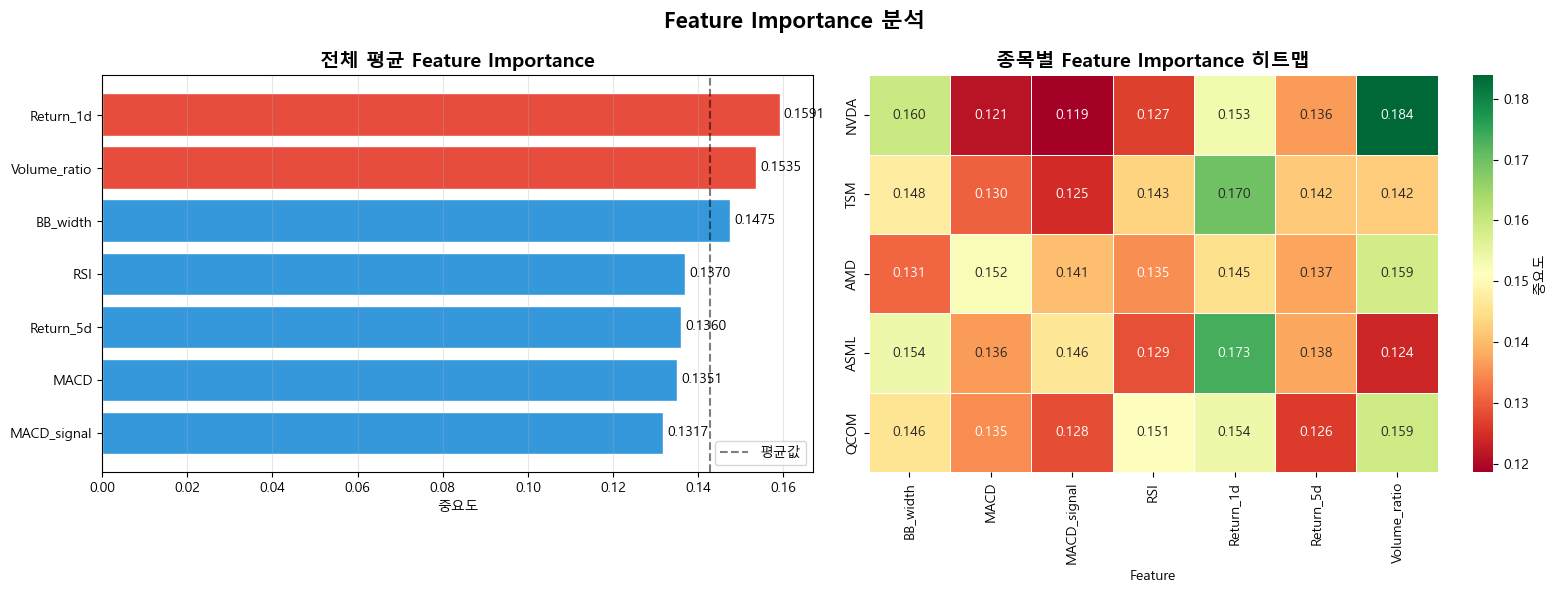

In [4]:
# ── Feature Importance ───────────────────────────────────────
all_importances = {}

for ticker in ["NVDA", "TSM", "AMD", "ASML", "QCOM"]:
    df_ticker = combined[combined["Ticker"] == ticker].copy()
    X_train, X_test, y_train, y_test = split_data(df_ticker)
    model_t = train_model(X_train, y_train)
    importance_df = get_feature_importance(model_t)
    all_importances[ticker] = importance_df.set_index("Feature")["Importance"]

importance_combined = pd.DataFrame(all_importances).T
mean_importance = importance_combined.mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ["#e74c3c" if i < 2 else "#3498db" for i in range(len(mean_importance))]
axes[0].barh(mean_importance.index[::-1], mean_importance.values[::-1],
             color=colors[::-1], edgecolor="white")
axes[0].axvline(x=mean_importance.mean(), color="black", 
                linestyle="--", alpha=0.5, label="평균값")
axes[0].set_title("전체 평균 Feature Importance", fontsize=14, fontweight="bold")
axes[0].set_xlabel("중요도")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="x")
for i, (val, name) in enumerate(zip(mean_importance.values[::-1], mean_importance.index[::-1])):
    axes[0].text(val + 0.001, i, f"{val:.4f}", va="center", fontsize=10)

sns.heatmap(importance_combined, annot=True, fmt=".3f",
            cmap="RdYlGn", ax=axes[1], linewidths=0.5,
            cbar_kws={"label": "중요도"})
axes[1].set_title("종목별 Feature Importance 히트맵", fontsize=14, fontweight="bold")

plt.suptitle("Feature Importance 분석", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/figures/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. 백테스팅

### 전략 설명
- 모델의 상승 확률 ≥ 0.6 (60%) 인 날만 매수
- 다음날 종가에 매도 (1일 보유)
- Buy & Hold 전략과 성과 비교

### 평가 지표
| 지표 | 설명 |
|------|------|
| 총 수익률 | 전략 전체 기간 누적 수익 |
| MDD | 최대 낙폭 (하락장 방어력) |
| 샤프 지수 | 수익 대비 리스크 비율 |
| 승률 | 매수 신호 중 실제 상승 비율 |

학습 데이터: 1581행 (2018-02-20 ~ 2024-05-31)
테스트 데이터: 396행  (2024-06-03 ~ 2025-12-30)
모델 학습 완료

정확도 (Accuracy) : 0.5455
AUC Score         : 0.5337

분류 리포트:
              precision    recall  f1-score   support

       하락(0)       0.52      0.44      0.47       186
       상승(1)       0.56      0.64      0.60       210

    accuracy                           0.55       396
   macro avg       0.54      0.54      0.54       396
weighted avg       0.54      0.55      0.54       396

전체 396일 중 매수 신호: 20일 (5.1%)

백테스팅 성과 요약
전략 총 수익률  : 2.24%
Buy&Hold 수익률 : 63.16%
연간 수익률     : 1.42%
────────────────────────────────────────
전략 MDD        : -6.51%
Buy&Hold MDD    : -36.88%
────────────────────────────────────────
샤프 지수       : 0.2048
승률            : 55.00%
매수 신호 횟수  : 20회
학습 데이터: 1581행 (2018-02-20 ~ 2024-05-31)
테스트 데이터: 396행  (2024-06-03 ~ 2025-12-30)
모델 학습 완료

정확도 (Accuracy) : 0.5152
AUC Score         : 0.5670

분류 리포트:
              precision    recall  f1-score   support

       하락(0)       0.49   

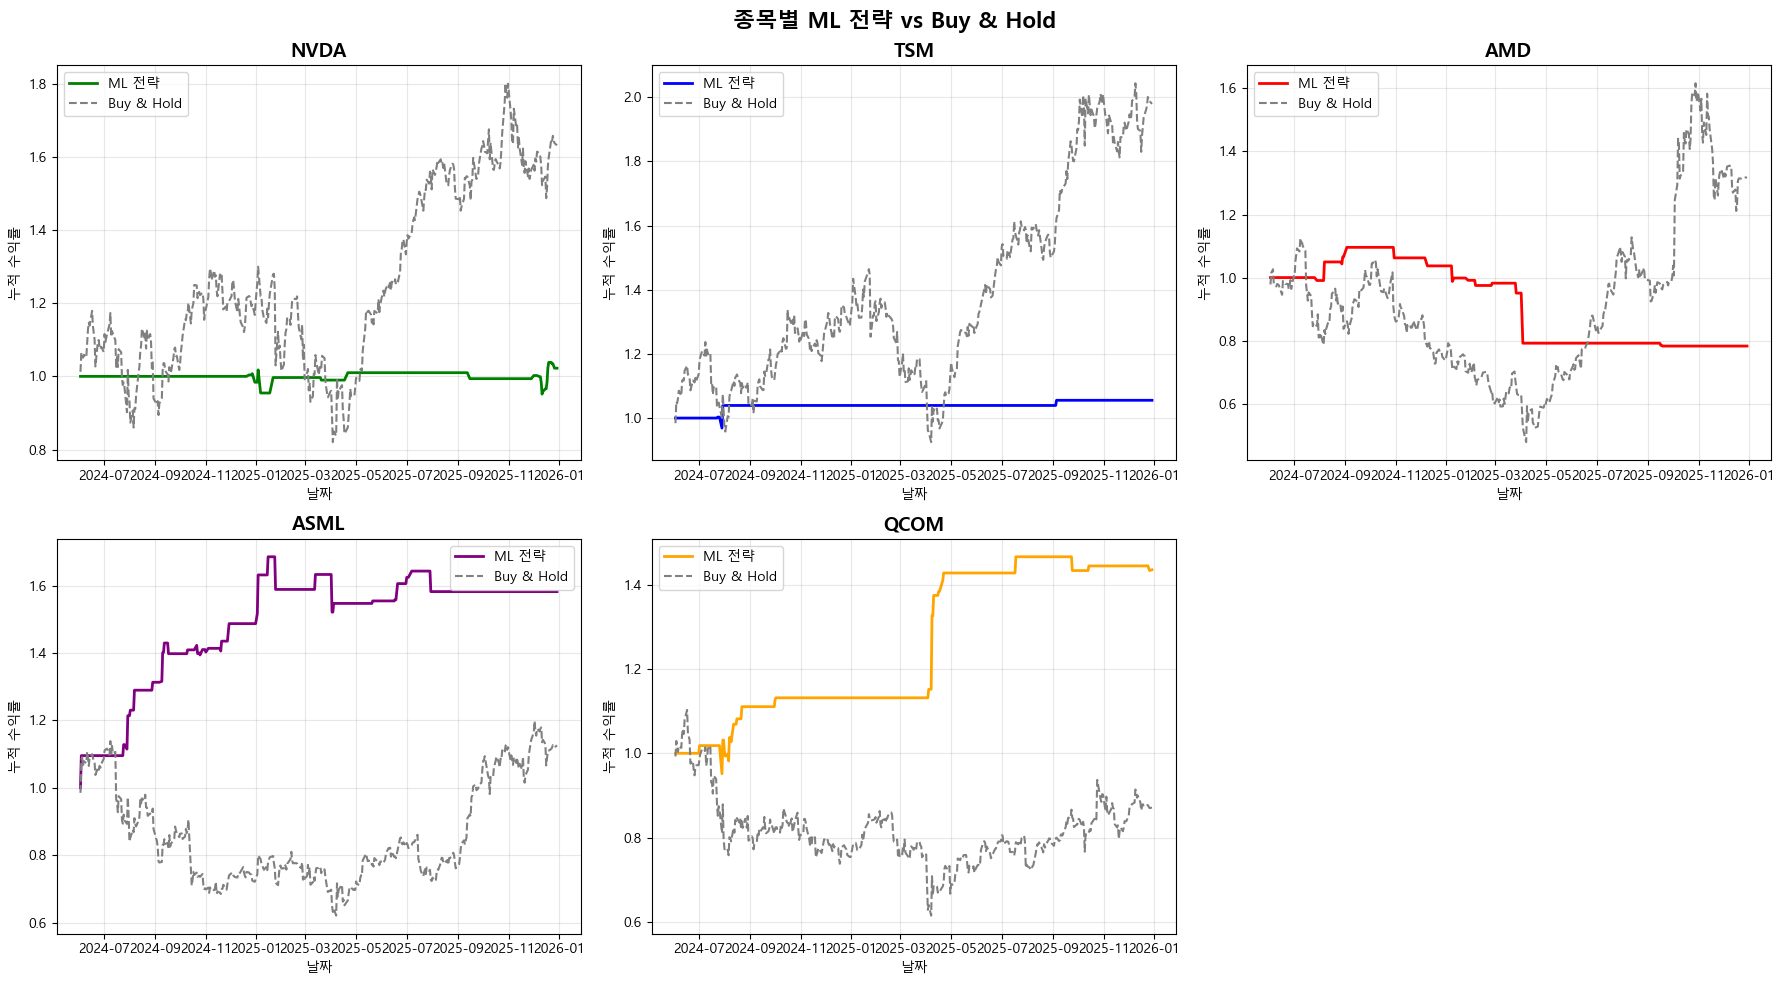


전체 종목 성과 요약


,총수익률,연수익률,MDD,샤프지수,승률
ticker,,,,,
NVDA,0.0224,0.0142,-0.0651,0.2048,0.5500
TSM,0.0554,0.0350,-0.0342,0.5567,0.7500
AMD,-0.2172,-0.1446,-0.2857,-1.1586,0.2941
ASML,0.5819,0.3399,-0.0975,1.7775,0.7500
QCOM,0.4352,0.2592,-0.0655,1.4381,0.7407


In [5]:
# ── 종목별 백테스팅 ──────────────────────────────────────────
all_results = []

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
colors = {"NVDA": "green", "TSM": "blue", "AMD": "red",
          "ASML": "purple", "QCOM": "orange"}

for i, ticker in enumerate(["NVDA", "TSM", "AMD", "ASML", "QCOM"]):
    try:
        df_ticker = combined[combined["Ticker"] == ticker].copy()
        X_train, X_test, y_train, y_test = split_data(df_ticker)
        model_t   = train_model(X_train, y_train)
        results_t = evaluate_model(model_t, X_test, y_test)
        test_df   = df_ticker.iloc[int(len(df_ticker) * 0.8):]
        signal_df = generate_signals(test_df, results_t["y_prob"], threshold=0.6)
        result_df = calculate_returns(signal_df)
        perf      = summarize_performance(result_df)

        if perf:
            all_results.append({"ticker": ticker, **perf})

        result_df = result_df.dropna()
        ax = axes[i]
        ax.plot(result_df.index, result_df["Strategy_cum"],
                label="ML 전략", color=colors[ticker], linewidth=2)
        ax.plot(result_df.index, result_df["BuyHold_cum"],
                label="Buy & Hold", color="gray", linewidth=1.5, linestyle="--")
        ax.set_title(f"{ticker}", fontsize=14, fontweight="bold")
        ax.set_xlabel("날짜")
        ax.set_ylabel("누적 수익률")
        ax.legend()
        ax.grid(True, alpha=0.3)

    except Exception as e:
        print(f"[{ticker}] 오류: {e}")

axes[-1].set_visible(False)
plt.suptitle("종목별 ML 전략 vs Buy & Hold", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/figures/cumulative_returns_all.png", dpi=150, bbox_inches="tight")
plt.show()

# 전체 성과 요약
summary = pd.DataFrame(all_results).set_index("ticker")
summary.columns = ["총수익률", "연수익률", "MDD", "샤프지수", "승률"]
print("\n전체 종목 성과 요약")
display(summary.round(4))

## 5. RSI 구간별 실제 상승 확률 검증

가설: "RSI 30 이하(과매도) 구간에서 실제 상승 확률이 더 높다"

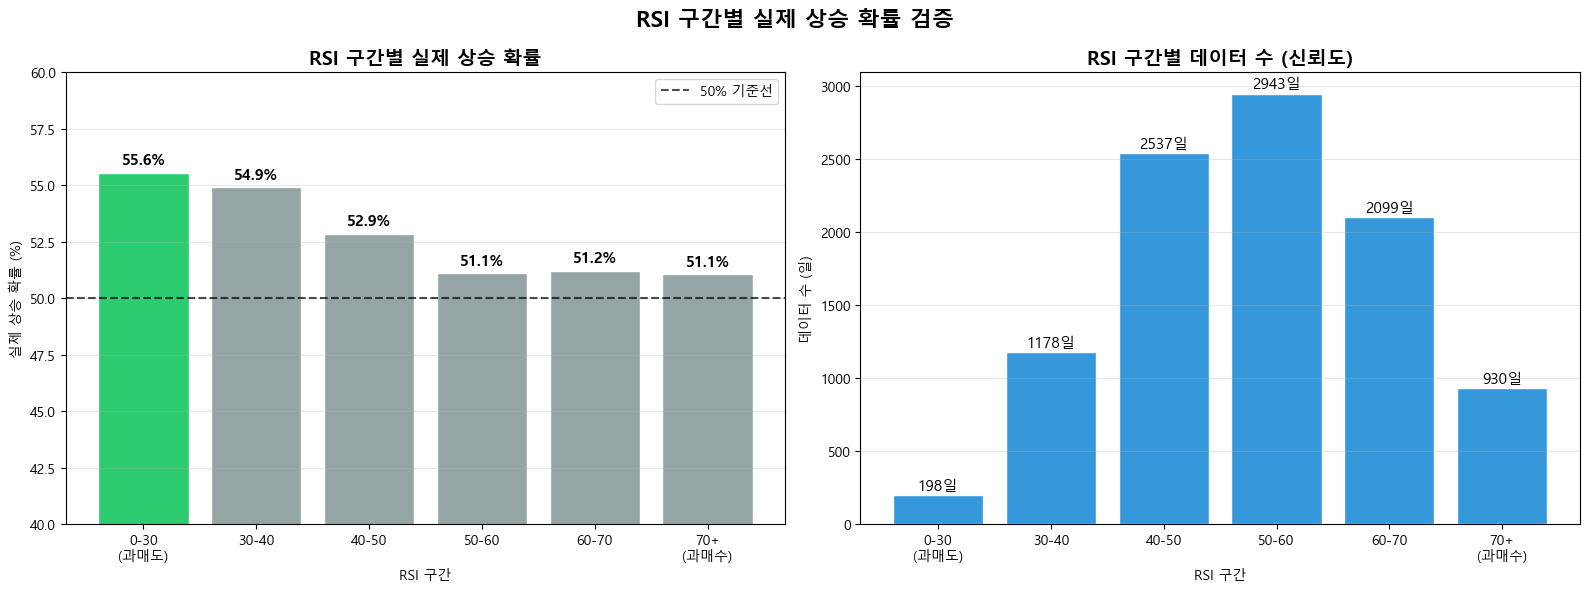

In [6]:
# ── RSI 구간별 실제 상승 확률 ────────────────────────────────
bins   = [0, 30, 40, 50, 60, 70, 100]
labels = ["0-30\n(과매도)", "30-40", "40-50",
          "50-60", "60-70", "70+\n(과매수)"]

combined["RSI_zone"] = pd.cut(combined["RSI"], bins=bins, labels=labels)
rsi_analysis = combined.groupby("RSI_zone", observed=True).agg(
    실제_상승확률=("Target", "mean"),
    데이터_수=("Target", "count")
).reset_index()
rsi_analysis["실제_상승확률"] *= 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
bar_colors = ["#2ecc71" if p >= 55 else "#e74c3c" if p <= 45 else "#95a5a6"
              for p in rsi_analysis["실제_상승확률"]]

bars = axes[0].bar(rsi_analysis["RSI_zone"], rsi_analysis["실제_상승확률"],
                   color=bar_colors, edgecolor="white")
axes[0].axhline(y=50, color="black", linestyle="--", alpha=0.7, label="50% 기준선")
axes[0].set_title("RSI 구간별 실제 상승 확률", fontsize=14, fontweight="bold")
axes[0].set_xlabel("RSI 구간")
axes[0].set_ylabel("실제 상승 확률 (%)")
axes[0].set_ylim(40, 60)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")
for bar, val in zip(bars, rsi_analysis["실제_상승확률"]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2, f"{val:.1f}%",
                 ha="center", va="bottom", fontsize=11, fontweight="bold")

axes[1].bar(rsi_analysis["RSI_zone"], rsi_analysis["데이터_수"],
            color="#3498db", edgecolor="white")
axes[1].set_title("RSI 구간별 데이터 수 (신뢰도)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("RSI 구간")
axes[1].set_ylabel("데이터 수 (일)")
axes[1].grid(True, alpha=0.3, axis="y")
for bar, val in zip(axes[1].patches, rsi_analysis["데이터_수"]):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 10, f"{val}일",
                 ha="center", va="bottom", fontsize=11)

plt.suptitle("RSI 구간별 실제 상승 확률 검증", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/figures/rsi_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Phase 1 결론

### 가설 검증 결과
| 가설 | 결과 |
|------|------|
| RSI가 유의미한 신호 | Feature Importance 4위 (0.137) |
| 거래량 변화율이 유의미한 신호 | Feature Importance 2위 (0.154) |
| RSI 30 이하에서 상승 확률 높음 | 55.6% (전체 평균 52% 대비 높음) |

### 백테스팅 성과
| 종목 | 총수익률 | MDD | 샤프지수 |
|------|---------|-----|---------|
| ASML | +58.2% | -9.75% | 1.78 |
| QCOM | +43.5% | -6.55% | 1.44 |
| TSM  | +5.5%  | -3.42% | 0.56 |
| NVDA | +2.2%  | -6.51% | 0.20 |
| AMD  | -21.7% | -28.57% | -1.16 |

### Phase 2 방향
- **PCA**: 중복 지표 노이즈 제거 후 성능 개선
- **LSTM**: 시계열 흐름을 학습하여 RF와 성과 비교
- **일반화 테스트**: 빅테크 섹터에 적용하여 섹터 특화 유효성 검증